# AI ile Kalp Hastalığı Tahmini

Bu workshopta gerçek bir sağlık veri seti kullanarak basit bir makine öğrenmesi modeli oluşturacağız.

Amacımız şu soruya cevap aramak:

**Bir bilgisayar yalnızca bazı tıbbi verilere bakarak kalp hastalığı riskini tahmin edebilir mi?**

Workshop boyunca şu adımları izleyeceğiz:

1. Veri setini inceleme  
2. Veriyi makine öğrenmesine hazırlama  
3. Logistic Regression modeli eğitme  
4. Model performansını değerlendirme  
5. Yeni bir hasta için tahmin yapma  
6. Modelin kararını açıklama

## Veri Setini Yükleme

Şimdi veri setini Python kullanarak yükleyeceğiz.

Veri analizi için en çok kullanılan Python kütüphanelerinden biri **pandas**'tır.

Pandas veri setlerini tablo şeklinde yönetmemizi sağlar.

CSV dosyasını okuduğumuzda Python içinde bir **DataFrame** oluşur.

DataFrame, Excel tablosuna benzer bir veri yapısıdır.

In [ ]:
import pandas as pd

##Pandas ile okunabilen diğer dosya formatları

Excel dosyaları

pd.read_excel("data.xlsx")

JSON dosyaları

pd.read_json("data.json")

JSON formatı özellikle web servisleri ve API'ler ile veri alışverişinde çok yaygın olarak kullanılır.

SQL veritabanları

pd.read_sql(query, connection)

Bu fonksiyon veritabanlarından veri çekmek için kullanılır.

Örneğin bir hastane veri tabanındaki hasta kayıtları bu şekilde okunabilir.

Parquet formatı

pd.read_parquet("data.parquet")

Parquet formatı özellikle büyük veri projelerinde kullanılır çünkü daha hızlıdır ve daha az yer kaplar.

In [ ]:
data = pd.read_csv("heart.csv")

In [ ]:
print(X.columns)


Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA',
       'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH',
       'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N',
       'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')


## Veri Setini İnceleme

Makine öğrenmesi projelerinde en önemli adımlardan biri veriyi anlamaktır.

Veri setini incelemek için bazı temel fonksiyonlar kullanırız.

**head()**

Veri setinin ilk satırlarını gösterir.



In [ ]:
print(data.head())

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  


**info()**

Veri setindeki kolonları ve veri tiplerini gösterir.


In [ ]:
print("\nDataset hakkında genel bilgi:\n")
print(data.info())


Dataset hakkında genel bilgi:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None



**describe()**

Sayısal verilerin istatistiksel özetini verir.

Bu bilgiler veri setinin yapısını anlamamıza yardımcı olur.

In [ ]:
print("\nİstatistiksel özet:\n")
print(data.describe())


İstatistiksel özet:

              Age   RestingBP  Cholesterol   FastingBS       MaxHR  \
count  918.000000  918.000000   918.000000  918.000000  918.000000   
mean    53.510893  132.396514   198.799564    0.233115  136.809368   
std      9.432617   18.514154   109.384145    0.423046   25.460334   
min     28.000000    0.000000     0.000000    0.000000   60.000000   
25%     47.000000  120.000000   173.250000    0.000000  120.000000   
50%     54.000000  130.000000   223.000000    0.000000  138.000000   
75%     60.000000  140.000000   267.000000    0.000000  156.000000   
max     77.000000  200.000000   603.000000    1.000000  202.000000   

          Oldpeak  HeartDisease  
count  918.000000    918.000000  
mean     0.887364      0.553377  
std      1.066570      0.497414  
min     -2.600000      0.000000  
25%      0.000000      0.000000  
50%      0.600000      1.000000  
75%      1.500000      1.000000  
max      6.200000      1.000000  


## Veri Dağılımını İnceleme

Makine öğrenmesi modelleri oluştururken veri dağılımını incelemek önemlidir.

Örneğin veri setinde kaç kişinin kalp hastalığı olduğunu görmek için:

value_counts() fonksiyonunu kullanabiliriz.

Ayrıca grafikler kullanarak veri dağılımını daha kolay görebiliriz.

Grafikler veri setindeki dengesizlikleri veya örüntüleri anlamamıza yardımcı olur.

In [ ]:
print("\nKalp hastalığı dağılımı:\n")
print(data["HeartDisease"].value_counts())


Kalp hastalığı dağılımı:

HeartDisease
1    508
0    410
Name: count, dtype: int64


## Veri Görselleştirme – Matplotlib ve Seaborn

Veri analizi yaparken sayısal tablolar her zaman yeterli değildir.  
Veriyi daha kolay anlayabilmek için grafikler kullanırız.

Python'da veri görselleştirme için en çok kullanılan iki kütüphane:

- **Matplotlib**
- **Seaborn**

Bu workshopta bu iki kütüphaneyi kullanacağız.

---

### Matplotlib

Matplotlib, Python'daki en temel grafik çizim kütüphanelerinden biridir.

Genellikle şu şekilde import edilir:

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

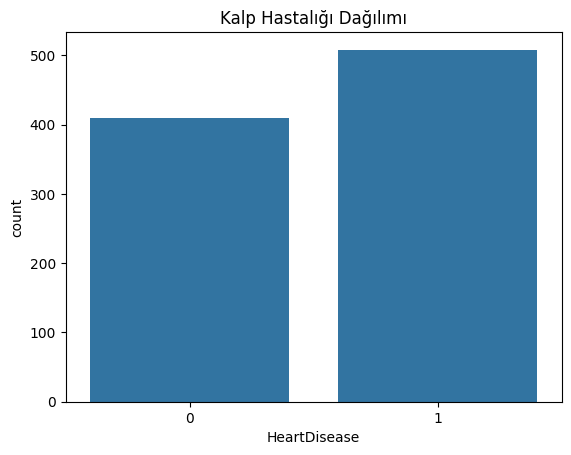

In [ ]:
sns.countplot(x="HeartDisease", data=data)
plt.title("Kalp Hastalığı Dağılımı")
plt.show()

In [ ]:
print("\nKolon tipleri:\n")
print(data.dtypes)


Kolon tipleri:

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object


Veri ve Sonuç setimizi belirliyoruz

In [ ]:
X = data.drop("HeartDisease", axis=1) # modelin kullanacağı veriler / axis = 0 satır axis = 1 kolon
y = data["HeartDisease"] # tahmin etmek istediğimiz sonuç

## Makine Öğrenmesi İçin Veri Hazırlama

Makine öğrenmesi algoritmaları sadece sayısal verilerle çalışabilir.

Bu yüzden kategorik verileri sayısal hale getirmemiz gerekir.

Örneğin:

Sex → M / F

Bu veri şu şekilde dönüştürülebilir:

Sex_M  
Sex_F

Bu yönteme **One Hot Encoding** denir.

Python'da bunu yapmak için pandas kütüphanesindeki **get_dummies()** fonksiyonunu kullanabiliriz.

Label Encoding

Label Encoding her kategoriye bir sayı atar.

Örneğin:

M → 0
F → 1

Python'da şu şekilde uygulanabilir:

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

X["Sex"] = encoder.fit_transform(X["Sex"])

Bu yöntem kategori sayısı az olduğunda kullanılabilir.

Ancak bazı durumlarda model kategoriler arasında sıralı bir ilişki olduğunu varsayabilir, bu yüzden dikkatli kullanılmalıdır.

OneHotEncoder (Scikit-Learn)

Scikit-learn içinde de One Hot Encoding yapan bir araç vardır.

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()

encoded = encoder.fit_transform(X)

Bu yöntem özellikle pipeline kurarken tercih edilir.

Ordinal Encoding

Eğer kategoriler arasında doğal bir sıralama varsa kullanılabilir.

Örneğin:

Low → 0
Medium → 1
High → 2

Python'da şu şekilde yapılabilir:

from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()

X_encoded = encoder.fit_transform(X)
Mapping (Elle Dönüştürme)

Bazen kategorileri manuel olarak sayıya çevirmek daha mantıklı olabilir.

Örneğin:

X["Sex"] = X["Sex"].map({
    "M": 1,
    "F": 0
})

Bu yöntem küçük veri setlerinde oldukça pratiktir.

In [ ]:
X = pd.get_dummies(X)
print(X)

     Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  Sex_F  Sex_M  \
0     40        140          289          0    172      0.0  False   True   
1     49        160          180          0    156      1.0   True  False   
2     37        130          283          0     98      0.0  False   True   
3     48        138          214          0    108      1.5   True  False   
4     54        150          195          0    122      0.0  False   True   
..   ...        ...          ...        ...    ...      ...    ...    ...   
913   45        110          264          0    132      1.2  False   True   
914   68        144          193          1    141      3.4  False   True   
915   57        130          131          0    115      1.2  False   True   
916   57        130          236          0    174      0.0   True  False   
917   38        138          175          0    173      0.0  False   True   

     ChestPainType_ASY  ChestPainType_ATA  ChestPainType_NAP  \
0          

## Training ve Test Veri Seti

Makine öğrenmesi modelleri eğitilirken veri genellikle ikiye bölünür.

Training Data → modelin öğrenmesi için kullanılır  
Test Data → modelin performansını ölçmek için kullanılır

Genellikle veri şu şekilde bölünür:

%80 training  
%20 test

Bu yöntem modelin daha önce görmediği veriler üzerinde test edilmesini sağlar.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Veri Normalizasyonu – StandardScaler

Makine öğrenmesi algoritmaları bazı durumlarda farklı ölçeklerdeki verilerden etkilenebilir.

Örneğin veri setinde şu iki değişken olduğunu düşünelim:

Age → 20 - 80 arası değerler  
Cholesterol → 100 - 600 arası değerler

Bu durumda model kolesterol değerlerini daha önemli sanabilir çünkü sayısal olarak çok daha büyük değerler içerir.

Bu problemi çözmek için verileri **ölçeklendirme (scaling)** işlemi yaparız.

Bu workshopta bunun için **StandardScaler** kullanıyoruz.

---

### StandardScaler Nedir?

StandardScaler verileri şu formüle göre dönüştürür:

\[
z = \frac{x - \mu}{\sigma}
\]

Burada:

x → veri değeri  
μ → ortalama  
σ → standart sapma  

Bu işlem sonucunda veriler:

- ortalama = 0
- standart sapma = 1

olacak şekilde yeniden ölçeklendirilir.

---


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

Burada iki işlem aynı anda yapılır:

fit()

Training verisinin ortalama ve standart sapmasını hesaplar.

transform()

Verileri bu değerlere göre normalize eder.

Yani:

1️ ortalama hesaplanır

2️ standart sapma hesaplanır

3️ veri ölçeklendirilir

In [ ]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Burada yalnızca transform() kullanıyoruz.

Çünkü test verisi modelin hiç görmediği veri olmalıdır.

Eğer test verisi üzerinde tekrar fit() yapılırsa model test verisi hakkında bilgi öğrenmiş olur ve bu durum data leakage adı verilen bir probleme yol açar.

Bu yüzden:

Training veri → fit + transform
Test veri → sadece transform

kullanılır.

## Model Oluşturma – Logistic Regression

Bu workshopta Logistic Regression algoritmasını kullanacağız.

Logistic Regression, özellikle **binary classification** problemleri için kullanılır.

Binary classification şu anlama gelir:

iki farklı sınıfı ayırt etmek.

Örneğin:

- hasta
- hasta değil

Model veri setindeki değişkenler arasındaki ilişkiyi öğrenir ve yeni veriler için tahmin yapabilir.

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## Model Performansını Ölçme

Model eğitildikten sonra performansını ölçmemiz gerekir.

En basit metriklerden biri **accuracy**'dir.

Accuracy şu şekilde hesaplanır:

Doğru tahmin sayısı / toplam tahmin sayısı

Örneğin model doğruluğu %85 ise model tahminlerin %85'ini doğru yapmıştır.

In [ ]:
accuracy = model.score(X_test, y_test)

print("\nModel doğruluğu:", accuracy)


Model doğruluğu: 0.8532608695652174


## Modelin Hangi Verilere Baktığını Anlamak

Makine öğrenmesi modelleri karar verirken bazı değişkenlere diğerlerinden daha fazla önem verir.

Logistic Regression modelinde bu bilgiler **coef_** değerlerinde saklanır.

Bu katsayılar her değişkenin model üzerindeki etkisini gösterir.

Pozitif değer → riski artıran faktör  
Negatif değer → riski azaltan faktör

Bu değerleri grafik olarak görselleştirmek mümkündür.

In [ ]:
importance = model.coef_[0]

feature_names = X.columns

for name, value in zip(feature_names, importance):
    print(name, value)

Age 0.14045935344862429
RestingBP 0.032203998957190595
Cholesterol -0.5232966505852011
FastingBS 0.42968575553583077
MaxHR -0.09886157737735879
Oldpeak 0.4878034976123707
Sex_F -0.2728672919190141
Sex_M 0.2728672919190141
ChestPainType_ASY 0.43621257698365934
ChestPainType_ATA -0.23949190517210917
ChestPainType_NAP -0.26977145580934647
ChestPainType_TA -0.056090346983758754
RestingECG_LVH 0.08946065217532469
RestingECG_Normal 0.0038980095124392148
RestingECG_ST -0.09617832428717718
ExerciseAngina_N -0.2695722855780948
ExerciseAngina_Y 0.2695722855780948
ST_Slope_Down -0.02842639787902676
ST_Slope_Flat 0.6054966585277921
ST_Slope_Up -0.5991793883396781


## Feature Importance Grafiği

Makine öğrenmesi modeli eğitildikten sonra önemli bir soru ortaya çıkar:

**Model karar verirken hangi değişkenlere daha fazla önem verdi?**

Logistic Regression modelinde her değişken için bir **katsayı (coefficient)** hesaplanır.  
Bu katsayılar modelin o değişkene ne kadar ağırlık verdiğini gösterir.

Bu değerleri daha kolay yorumlayabilmek için bir grafik oluşturuyoruz.

---

### Kodun Açıklaması


import matplotlib.pyplot as plt

Bu satır Matplotlib kütüphanesinin grafik çizme modülünü içeri aktarır.

plt.figure(figsize=(10,6))

Bu fonksiyon grafik için bir çizim alanı oluşturur.

figsize parametresi grafiğin boyutunu belirler.

Burada:

genişlik = 10

yükseklik = 6

olarak ayarlanmıştır.

plt.barh(feature_names, importance)

Bu fonksiyon yatay çubuk grafik (horizontal bar chart) oluşturur.

Grafikte:

feature_names → veri setindeki değişkenlerin isimleri

importance → modelin hesapladığı katsayı değerleri

Bu grafik sayesinde hangi değişkenlerin model üzerinde daha güçlü etkisi olduğunu görebiliriz.

Pozitif değerler genellikle riski artıran faktörleri,
negatif değerler ise riski azaltan faktörleri temsil edebilir.

plt.title("Feature Importance")

Bu fonksiyon grafiğin başlığını belirler.

plt.show()

Bu komut grafiğin ekranda gösterilmesini sağlar.

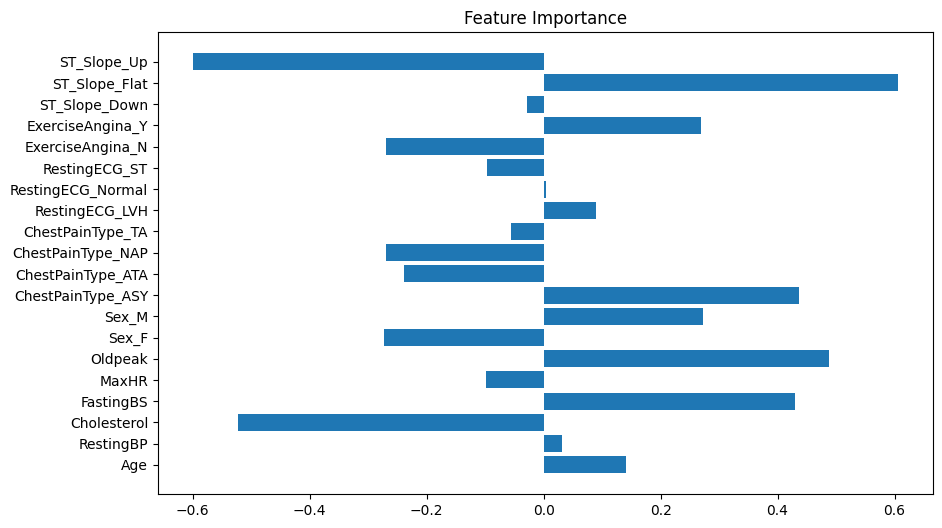

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(feature_names, importance)

plt.title("Feature Importance")

plt.show()

In [ ]:
sample_patient = X.iloc[0:1] # slicing
sample_patient = scaler.transform(sample_patient)



In [ ]:
prediction = model.predict(sample_patient)

print("Tahmin:", prediction)

Tahmin: [0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


## Yeni Bir Hasta İçin Tahmin

Model eğitildikten sonra yeni bir hasta için tahmin yapılabilir.

Bunun için hastanın klinik verilerini modele veririz.

Model iki farklı çıktı üretir:

Tahmin edilen sınıf  
Risk olasılığı

Örneğin:

Model bu hastanın kalp hastalığı riskini %78 olarak tahmin edebilir.

In [ ]:
# Datasetten bir hastayı kopyala
new_patient = X.iloc[[0]].copy()

# Hastanın bazı değerlerini değiştir
new_patient["Age"] = 20

new_patient["RestingBP"] = 120
new_patient["Cholesterol"] = 220
new_patient["MaxHR"] = 170
new_patient["Oldpeak"] = 2.0

In [ ]:
# Veriyi aynı scaler ile normalize et
new_patient = scaler.transform(new_patient)


In [ ]:
# Tahmin yap
prediction = model.predict(new_patient)

# Risk olasılığını hesapla
probability = model.predict_proba(new_patient)

print("\nAI Tahmini:", prediction[0])
print("Hastalık olasılığı:", probability[0][1])


AI Tahmini: 0
Hastalık olasılığı: 0.07429319307272476


## Explainable AI – SHAP

Makine öğrenmesi modelleri bazen "black box" olarak adlandırılır.

Yani modelin neden o kararı verdiğini anlamak zor olabilir.

SHAP yöntemi modelin kararlarını açıklamak için kullanılır.

SHAP grafikleri şu soruya cevap verir:

**Model bu hasta için neden risk dedi?**

Grafikte:

Kırmızı → riski artıran faktörler  
Mavi → riski azaltan faktörler

Bu yöntem özellikle sağlık alanında çok önemlidir çünkü model kararlarının açıklanmasını sağlar.

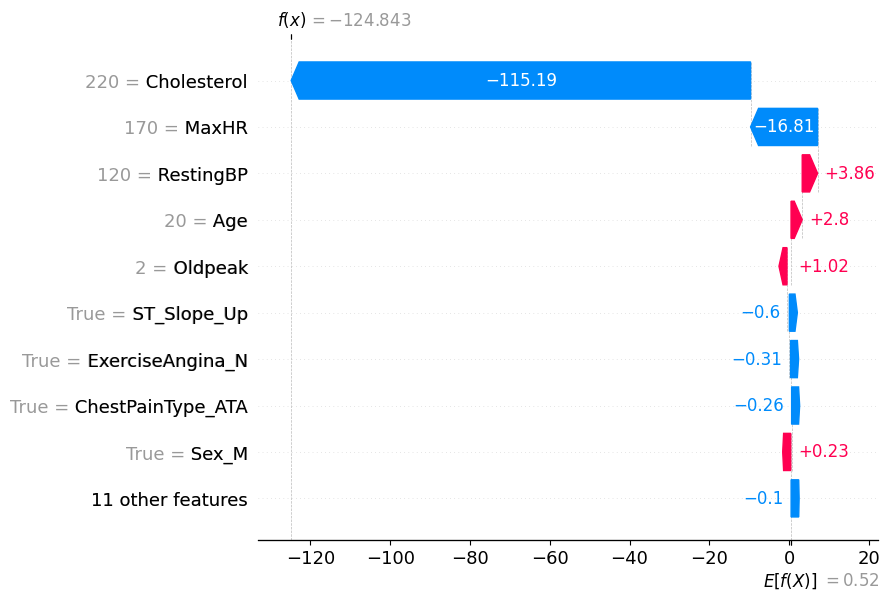

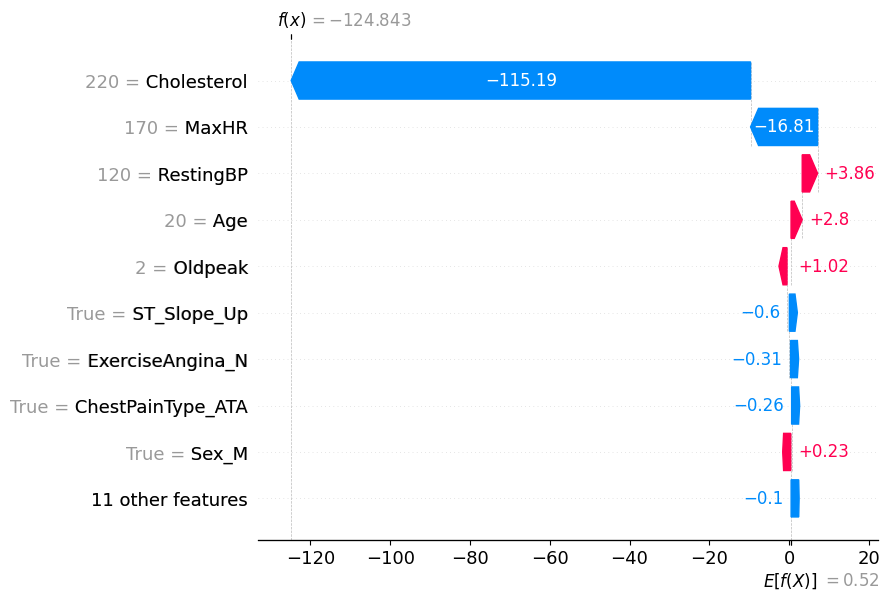

In [ ]:
import shap

explainer = shap.Explainer(model, X_train)

shap_values = explainer(new_patient)

shap.plots.waterfall(shap_values[0])


# shap.plots.waterfall(shap_values[0])

## Confusion Matrix

Accuracy tek başına yeterli değildir.

Bu yüzden Confusion Matrix kullanılır.

Confusion Matrix dört farklı sonucu gösterir:

True Positive → doğru hasta tahmini  
True Negative → doğru sağlıklı tahmini  
False Positive → sağlıklı ama hasta tahmin edildi  
False Negative → hasta ama sağlıklı tahmin edildi

Tıp alanında en kritik hata **False Negative**'dir.

Yani hasta bir kişinin sağlıklı tahmin edilmesi.

In [ ]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[67 10]
 [17 90]]


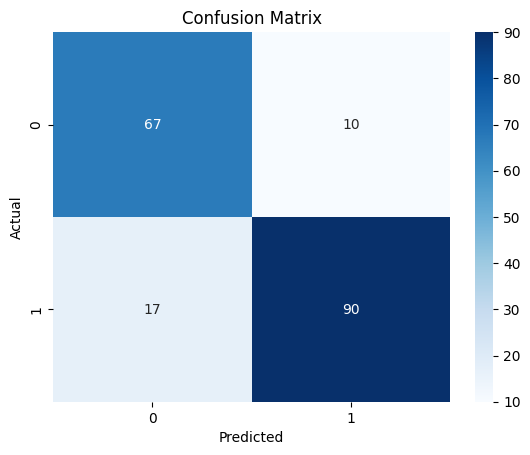

In [ ]:
import seaborn as sns
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()